<h1>Healthcare Premium Project</h1>

<h3>Problem Statement</h3>
S.H.E.I.L.D. Insurance, a major player in the Indian insurance sector, requires a specialized, data-driven solution to accurately predict healthcare insurance premiums for its youngest customer segment (ages 25 and under). Following the discovery that generalized models systematically misprice baseline policies for young, healthy singles, the objective of this project is to develop a targeted machine learning pricing model exclusively for this demographic. This segmented model will leverage applicant data to reliably estimate appropriate premium costs, ensuring equitable pricing, preventing extreme error margins, and protecting market share among early-career individuals.

<h3>Importing required libraries</h3>

In [1]:
import pandas as pd 
import numpy as np
import joblib
from matplotlib import pyplot as plt 
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso 
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder, OneHotEncoder
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error 
from statsmodels.stats.outliers_influence import variance_inflation_factor 
from sklearn.model_selection import train_test_split, cross_val_score 
from sklearn.model_selection import RandomizedSearchCV

<h3>Loading & standarding column names</h3>

Our team requested the three specific types of data discussed above (lifestyle, genetics, and claims). Because of the real-world constraints, the client could not provide everything.
Instead of the detailed data we wanted, the client was only able to provide a single, new "generic risk factor" column for this demographic.

In [2]:
df = pd.read_excel("data/premiums young with gr.xlsx")
print("Dataset Shape:", df.shape)
df

Dataset Shape: (20096, 14)


,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount,Genetical_Risk
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,4
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050,3
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,Silver,11857,4
3,25,Male,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,15,No Disease,Bronze,5684,2
4,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,10L - 25L,14,No Disease,Bronze,5712,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20091,18,Female,Southeast,Unmarried,0,Underweight,No Smoking,Freelancer,> 40L,91,No Disease,Gold,11603,1
20092,23,Female,Northwest,Unmarried,0,Obesity,Occasional,Freelancer,> 40L,57,Diabetes,Gold,14498,2
20093,24,Female,Northwest,Unmarried,0,Underweight,No Smoking,Self-Employed,25L - 40L,35,No Disease,Bronze,9111,5
20094,21,Male,Northwest,Unmarried,0,Normal,Regular,Freelancer,25L - 40L,32,No Disease,Bronze,8564,4


In [3]:
df.columns = [col.strip().replace(' ', '_').lower() for col in df.columns]
df.head(1)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,4


<h3> Handling missing (NA) values and duplicates</h3>

In [4]:
df.isna().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           2
employment_status        1
income_level             4
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
genetical_risk           0
dtype: int64

The dataset is remarkably clean, with missing values limited to just three columns: income_level (13), smoking_status (11), and employment_status (2). Given the total dataset size of 50,000 rows, these missing values make up a negligible fraction (less than 0.03%) and can likely be safely dropped or simply imputed without impacting your model.
Because our total dataset is massive (50,000 records), dropping these few rows will not negatively impact our analysis.

In [5]:
df.dropna(inplace = True)
df.isna().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
genetical_risk           0
dtype: int64

In [6]:
#Checking for duplicates
print(df.duplicated().sum())

0


<h3>Fixing data errors (dependents)</h3>

Using the `describe()` function helps us spot logical errors in numerical columns.

In [7]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount,genetical_risk
count,20090.000000,20090.000000,20090.000000,20090.000000,20090.000000
mean,21.494375,0.718019,22.510851,8142.096267,2.503932
std,2.294052,0.940713,23.420493,2749.906347,1.710203
min,18.000000,-3.000000,1.000000,3501.000000,0.000000
25%,19.000000,0.000000,6.000000,6022.250000,1.000000
50%,22.000000,0.000000,16.000000,7939.000000,3.000000
75%,23.000000,1.000000,31.000000,9561.000000,4.000000
max,25.000000,3.000000,790.000000,18186.000000,5.000000


The summary statistics reveal clear data entry errors requiring correction, specifically an impossible maximum `age` of 356 and a negative minimum for `number_of_dependants` (-3). Additionally, the maximum `income_lakhs` of 930 indicates an extreme outlier compared to its 75th percentile of 31.

In [8]:
print(df[df['number_of_dependants'] < 0].shape)
print(df[df['number_of_dependants'] < 0]['number_of_dependants'].unique())

(22, 14)
[-3 -1]


The team agrees the safest fix is to convert these to absolute (positive) numbers.

In [9]:
df.number_of_dependants = abs(df.number_of_dependants)
df.number_of_dependants.describe()

count    20090.000000
mean         0.722598
std          0.937200
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          3.000000
Name: number_of_dependants, dtype: float64

<h3>Outlier Treatment (General Philosophy)</h3>

We use box plots to visualize outliers. We do not blindly delete data just because a box plot shows dots. Sometimes, those extreme values are valid data points!

<h4>Visualize numeric columns</h4>

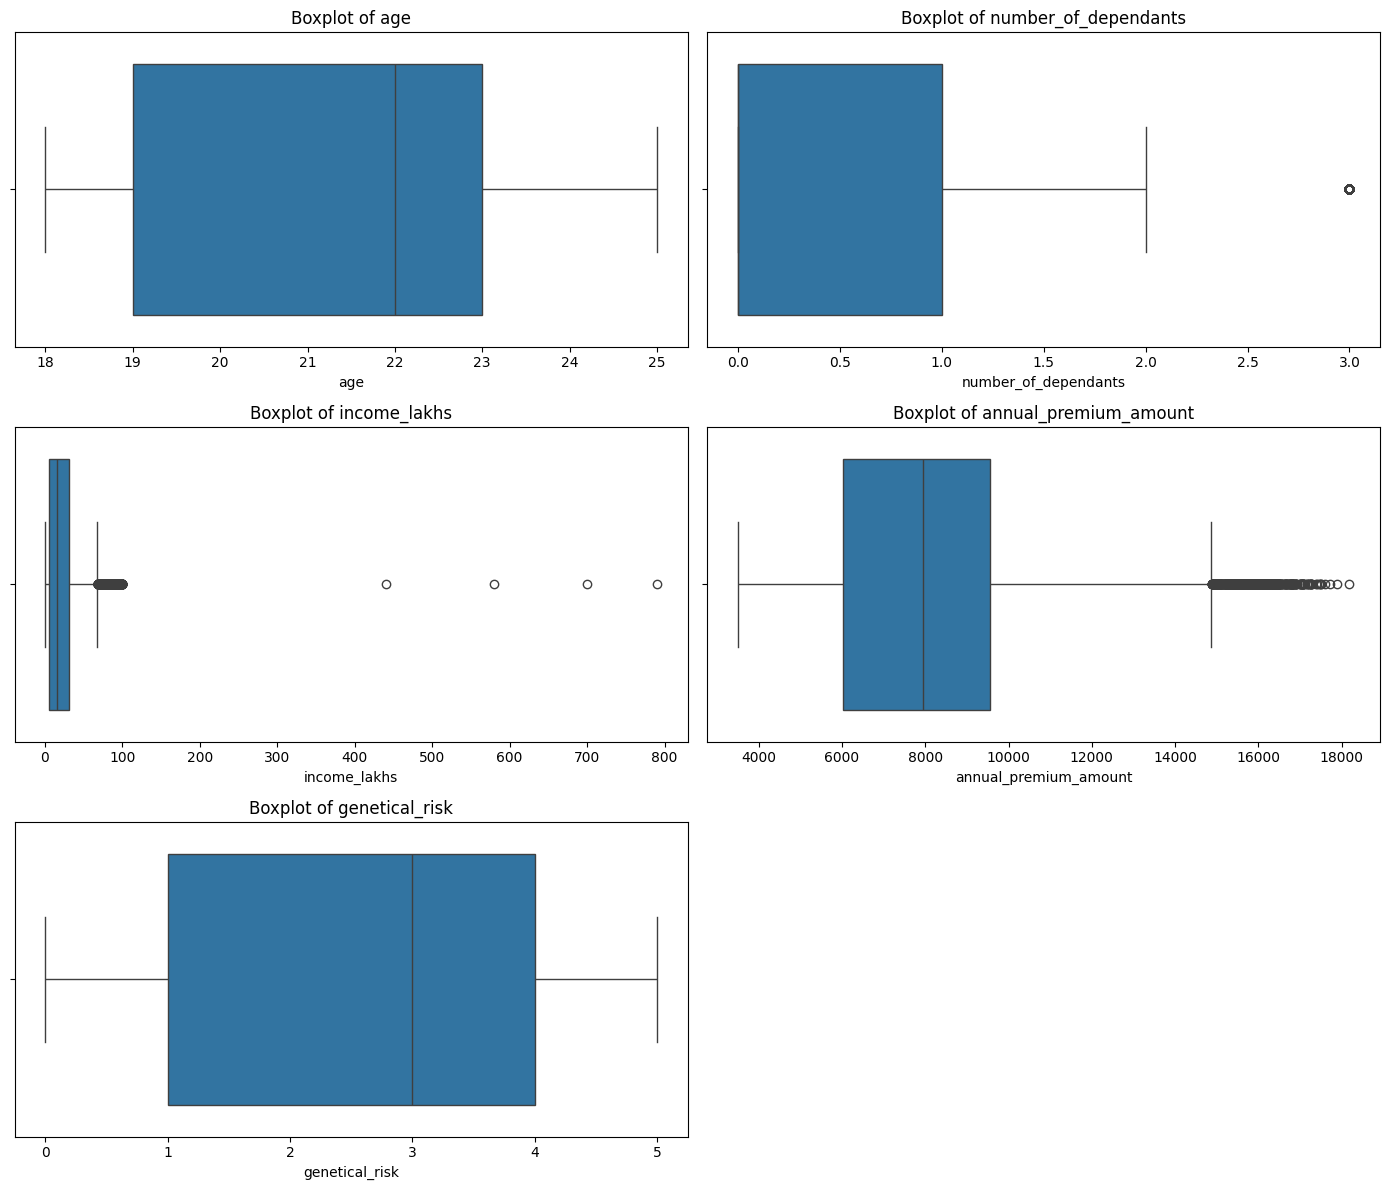

In [10]:
# Identify numeric columns
cols = df.select_dtypes(['int64', 'float64']).columns
num_cols = len(cols)

n_columns_grid = 2
n_rows_grid = int(np.ceil(num_cols / n_columns_grid))

fig, axes = plt.subplots(n_rows_grid, n_columns_grid, figsize=(14, 4 * n_rows_grid))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')
    
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

The boxplots visually confirm severe right-tail outliers in both `age` (with impossible values exceeding 100) and `income_lakhs` (heavily skewed with values reaching 900+). In contrast, `number_of_dependants` is perfectly bounded with no outliers, and `annual_premium_amount` shows a standard upper tail expected in premium pricing.

<h3>Outlier Treatment: Age</h3>

For the 'age' column, we do not need complex statistical formulas like IQR. We can use simple domain knowledge.

In [11]:
df[df.age > 100].age.unique()

array([], dtype=int64)

Humans do not live to be 356. These are clearly errors. We establish a logical threshold (age <= 100) and drop the rest.

In [12]:
df1 = df[df.age <= 100].copy()
df1.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount,genetical_risk
count,20090.000000,20090.000000,20090.000000,20090.000000,20090.000000
mean,21.494375,0.722598,22.510851,8142.096267,2.503932
std,2.294052,0.937200,23.420493,2749.906347,1.710203
min,18.000000,0.000000,1.000000,3501.000000,0.000000
25%,19.000000,0.000000,6.000000,6022.250000,1.000000
50%,22.000000,0.000000,16.000000,7939.000000,3.000000
75%,23.000000,1.000000,31.000000,9561.000000,4.000000
max,25.000000,3.000000,790.000000,18186.000000,5.000000


<h3>Outlier Treatment: Income</h3>

Before treating income outliers, always plot a distribution to understand the data's shape.

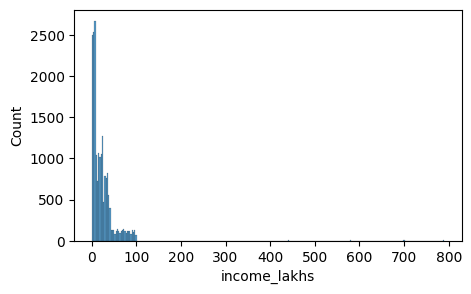

In [13]:
plt.figure(figsize = (5,3))
sns.histplot(df1.income_lakhs)
plt.show()

The histogram shows the vast majority of incomes fall within the 100 Lakhs range, but we have extreme values going much higher. 

First, we might try the standard IQR (Interquartile Range) method:

In [14]:
def get_iqr_bounds(col):
    q1, q3 = col.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return lower_bound, upper_bound

In [15]:
print(get_iqr_bounds(df1.income_lakhs))

(-31.5, 68.5)


**Why IQR Fails Here:** The lower bound (-29.0) is irrelevant since our minimum income is 1.0. More importantly, the upper bound is 67 Lakhs. In the context of the Indian market, an income of 67 Lakhs is certainly high, but it is not a statistical anomaly that warrants deletion. If we delete data above 67 Lakhs, we lose valuable information about high-net-worth individuals!

**The Solution (Percentiles):** Instead of IQR, we consult the team and agree to use a strict percentile threshold, such as the 99.9th percentile.

In [16]:
quantile_threshold = df1.income_lakhs.quantile(0.999)
quantile_threshold

np.float64(100.0)

In [17]:
df1[df1.income_lakhs > quantile_threshold].shape

(4, 14)

This means 99.9% of our data falls below 100 Lakhs (1 Crore), which is a much more reasonable cutoff. We drop these 10 extreme records.

In [18]:
df2 = df1[df1.income_lakhs <= quantile_threshold].copy()
df2.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount,genetical_risk
count,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000
mean,21.494474,0.722742,22.390371,8141.799263,2.503883
std,2.294248,0.937238,21.732062,2749.912486,1.710184
min,18.000000,0.000000,1.000000,3501.000000,0.000000
25%,19.000000,0.000000,6.000000,6022.000000,1.000000
50%,22.000000,0.000000,16.000000,7939.000000,3.000000
75%,23.000000,1.000000,31.000000,9561.000000,4.000000
max,25.000000,3.000000,100.000000,18186.000000,5.000000


<h3>Univariate analysis : Numeric distributions</h3>

We start by examining the distribution of our numeric columns. Visualizing the shape of the data helps us understand the spread and identify any skewness.

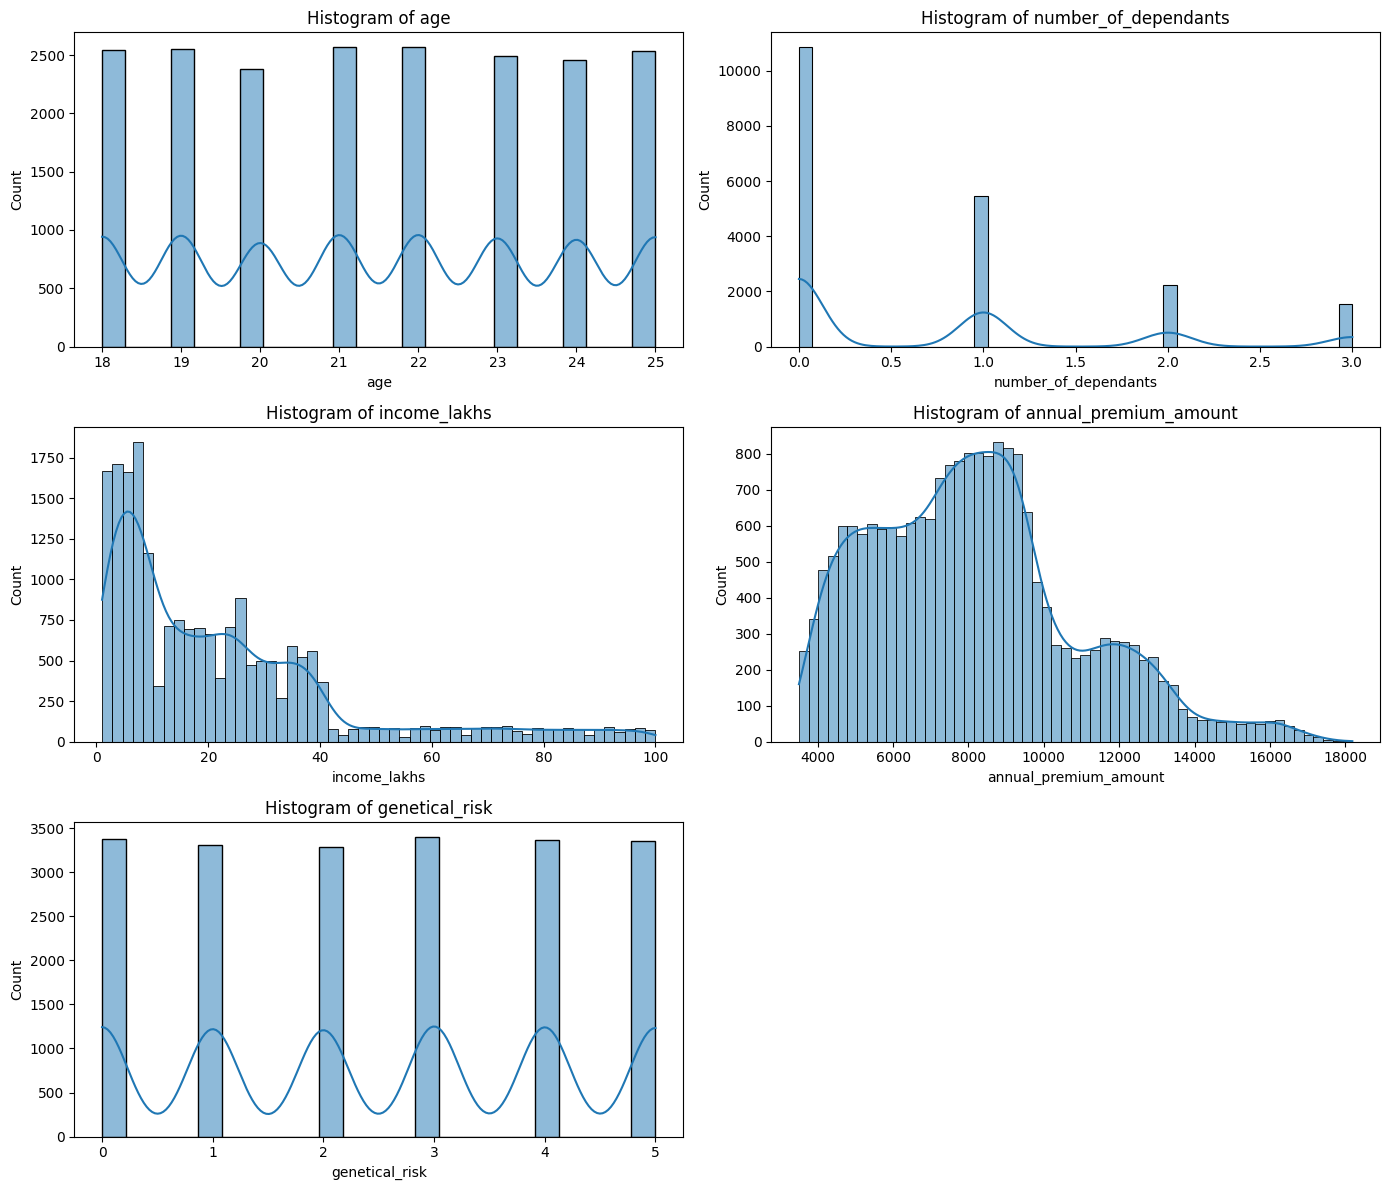

In [19]:
n_columns_grid = 2
n_rows_grid = int(np.ceil(num_cols / n_columns_grid))

fig, axes = plt.subplots(n_rows_grid, n_columns_grid, figsize=(14, 4 * n_rows_grid))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(x=df2[col], ax=axes[i], kde = True)
    axes[i].set_title(f'Histogram of {col}')
    
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

* The policyholder demographic skews significantly young, with the most pronounced concentration of customers falling between 18 and 25 years old, indicating strong market penetration among early-career individuals.

* The `genetical_risk` scores are uniformly distributed across all six levels (0 through 5). This indicates an evenly balanced risk pool without any disproportionate concentration of high or low genetic risk profiles.

* A vast majority of customers report an annual income well below 40 Lakhs (with a median of just 17 Lakhs), meaning core insurance products must remain competitively priced for middle-income earners. Very few policyholders have incomes approaching the 100 Lakhs threshold.

* The `number_of_dependants` distribution shows two distinct customer segments: a massive peak at zero dependents (singles) and a secondary peak at three dependents (standard nuclear families).

* Annual premium amounts are strongly clustered in the ₹8,000 to ₹22,000 range, which aligns perfectly with the purchasing power of the dominant income demographic.

* **Strategic Takeaway:** The business should prioritize low-cost, baseline plans to retain the massive younger, single segment, while utilizing targeted upsells (like family floaters) as they transition into the two-dependent demographic. The balanced genetic risk pool also allows for stable, predictable baseline pricing across these entry-level plans.

<h3>Bivariate Analysis : Numeric features vs Target</h3>

With our univariate analysis complete, we move to bivariate analysis to see how our numeric features relate to our target variable: the annual premium amount.

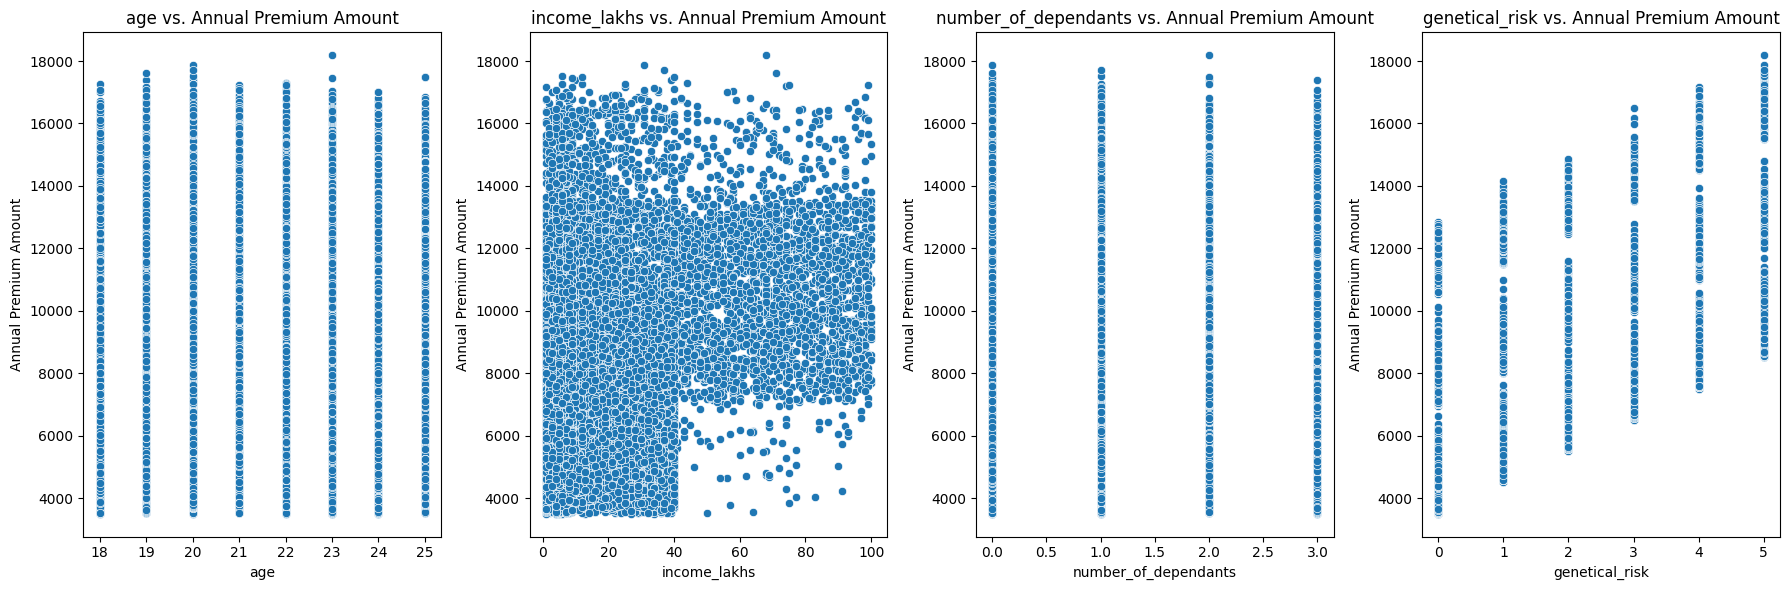

In [20]:
numeric_features = ['age', 'income_lakhs', 'number_of_dependants', 'genetical_risk']

fig, axes = plt.subplots(1, len(numeric_features), figsize=(18, 6)) 

for ax, column in zip(axes, numeric_features): 
    sns.scatterplot(x=df2[column], y=df2['annual_premium_amount'], ax=ax) 
    ax.set_title(f'{column} vs. Annual Premium Amount') 
    ax.set_xlabel(column) 
    ax.set_ylabel('Annual Premium Amount')
    
plt.tight_layout()  
plt.show()

* Although the age plot appears dense due to the volume of data, a clear tiered pattern emerges: as age increases, the annual premium amount rises in distinct "steps," validating age as a primary driver of pricing.
* These rigid vertical clusters in the age plot strongly suggest that the company currently utilizes predefined age brackets (e.g., steep jumps around ages 25 and 45) rather than calculating a continuous, individualized risk score.
* In the income scatter plot, policyholders earning below 45 Lakhs purchase plans across the entire price spectrum, but beyond this threshold, the minimum premium paid noticeably jumps, indicating higher earners naturally abandon entry-level plans.
* The number of dependents shows no strong positive correlation with higher premiums; costs remain highly variable for individuals and small families (0-3 dependents), making it a surprisingly weak standalone predictor for revenue.
* Interestingly, the highest absolute premium amounts are paid by those with 3 or fewer dependents, while the price ceiling actually drops for larger families (4-5 dependents), possibly reflecting affordability limits or capped family-floater policies.
* Overall, the distinct structural boundaries across these plots imply a legacy, rule-based pricing matrix; transitioning to an ML model will allow for smoother, more dynamic premium personalization.

<h3>Categorical Data : Handling  Inconsistencies</h3>

In [21]:
categorical_cols = df2.select_dtypes('object').columns

C:\Users\SRIJIT\AppData\Local\Temp\ipykernel_14772\433752136.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df2.select_dtypes('object').columns


In [22]:
for col in categorical_cols:
    print(f"{col} ==> {df2[col].unique().tolist()}")
    print("-"*150)

gender ==> ['Male', 'Female']
------------------------------------------------------------------------------------------------------------------------------------------------------
region ==> ['Northeast', 'Northwest', 'Southeast', 'Southwest']
------------------------------------------------------------------------------------------------------------------------------------------------------
marital_status ==> ['Unmarried', 'Married']
------------------------------------------------------------------------------------------------------------------------------------------------------
bmi_category ==> ['Overweight', 'Underweight', 'Normal', 'Obesity']
------------------------------------------------------------------------------------------------------------------------------------------------------
smoking_status ==> ['Regular', 'No Smoking', 'Occasional', 'Smoking=0', 'Does Not Smoke', 'Not Smoking']
-------------------------------------------------------------------------------------

Looking at the output for smoking_status, we see redundant values like 'Smoking = 0', 'Does Not Smoke', and 'Not Smoking'. During data collection, people or systems might have entered non-uniform text. We must consolidate these into a single category: 'No Smoking'.

In [23]:
df2.smoking_status = df2['smoking_status'].replace({
    "Smoking=0" : "No Smoking",
    "Does Not Smoke" : "No Smoking",
    "Not Smoking" : "No Smoking"
})

print(df2.smoking_status.unique())

<ArrowStringArray>
['Regular', 'No Smoking', 'Occasional']
Length: 3, dtype: str


<h3>Univariate Analysis: Categorical Features</h3>

With clean categories, we can now analyze their distributions using relative frequencies (percentages).

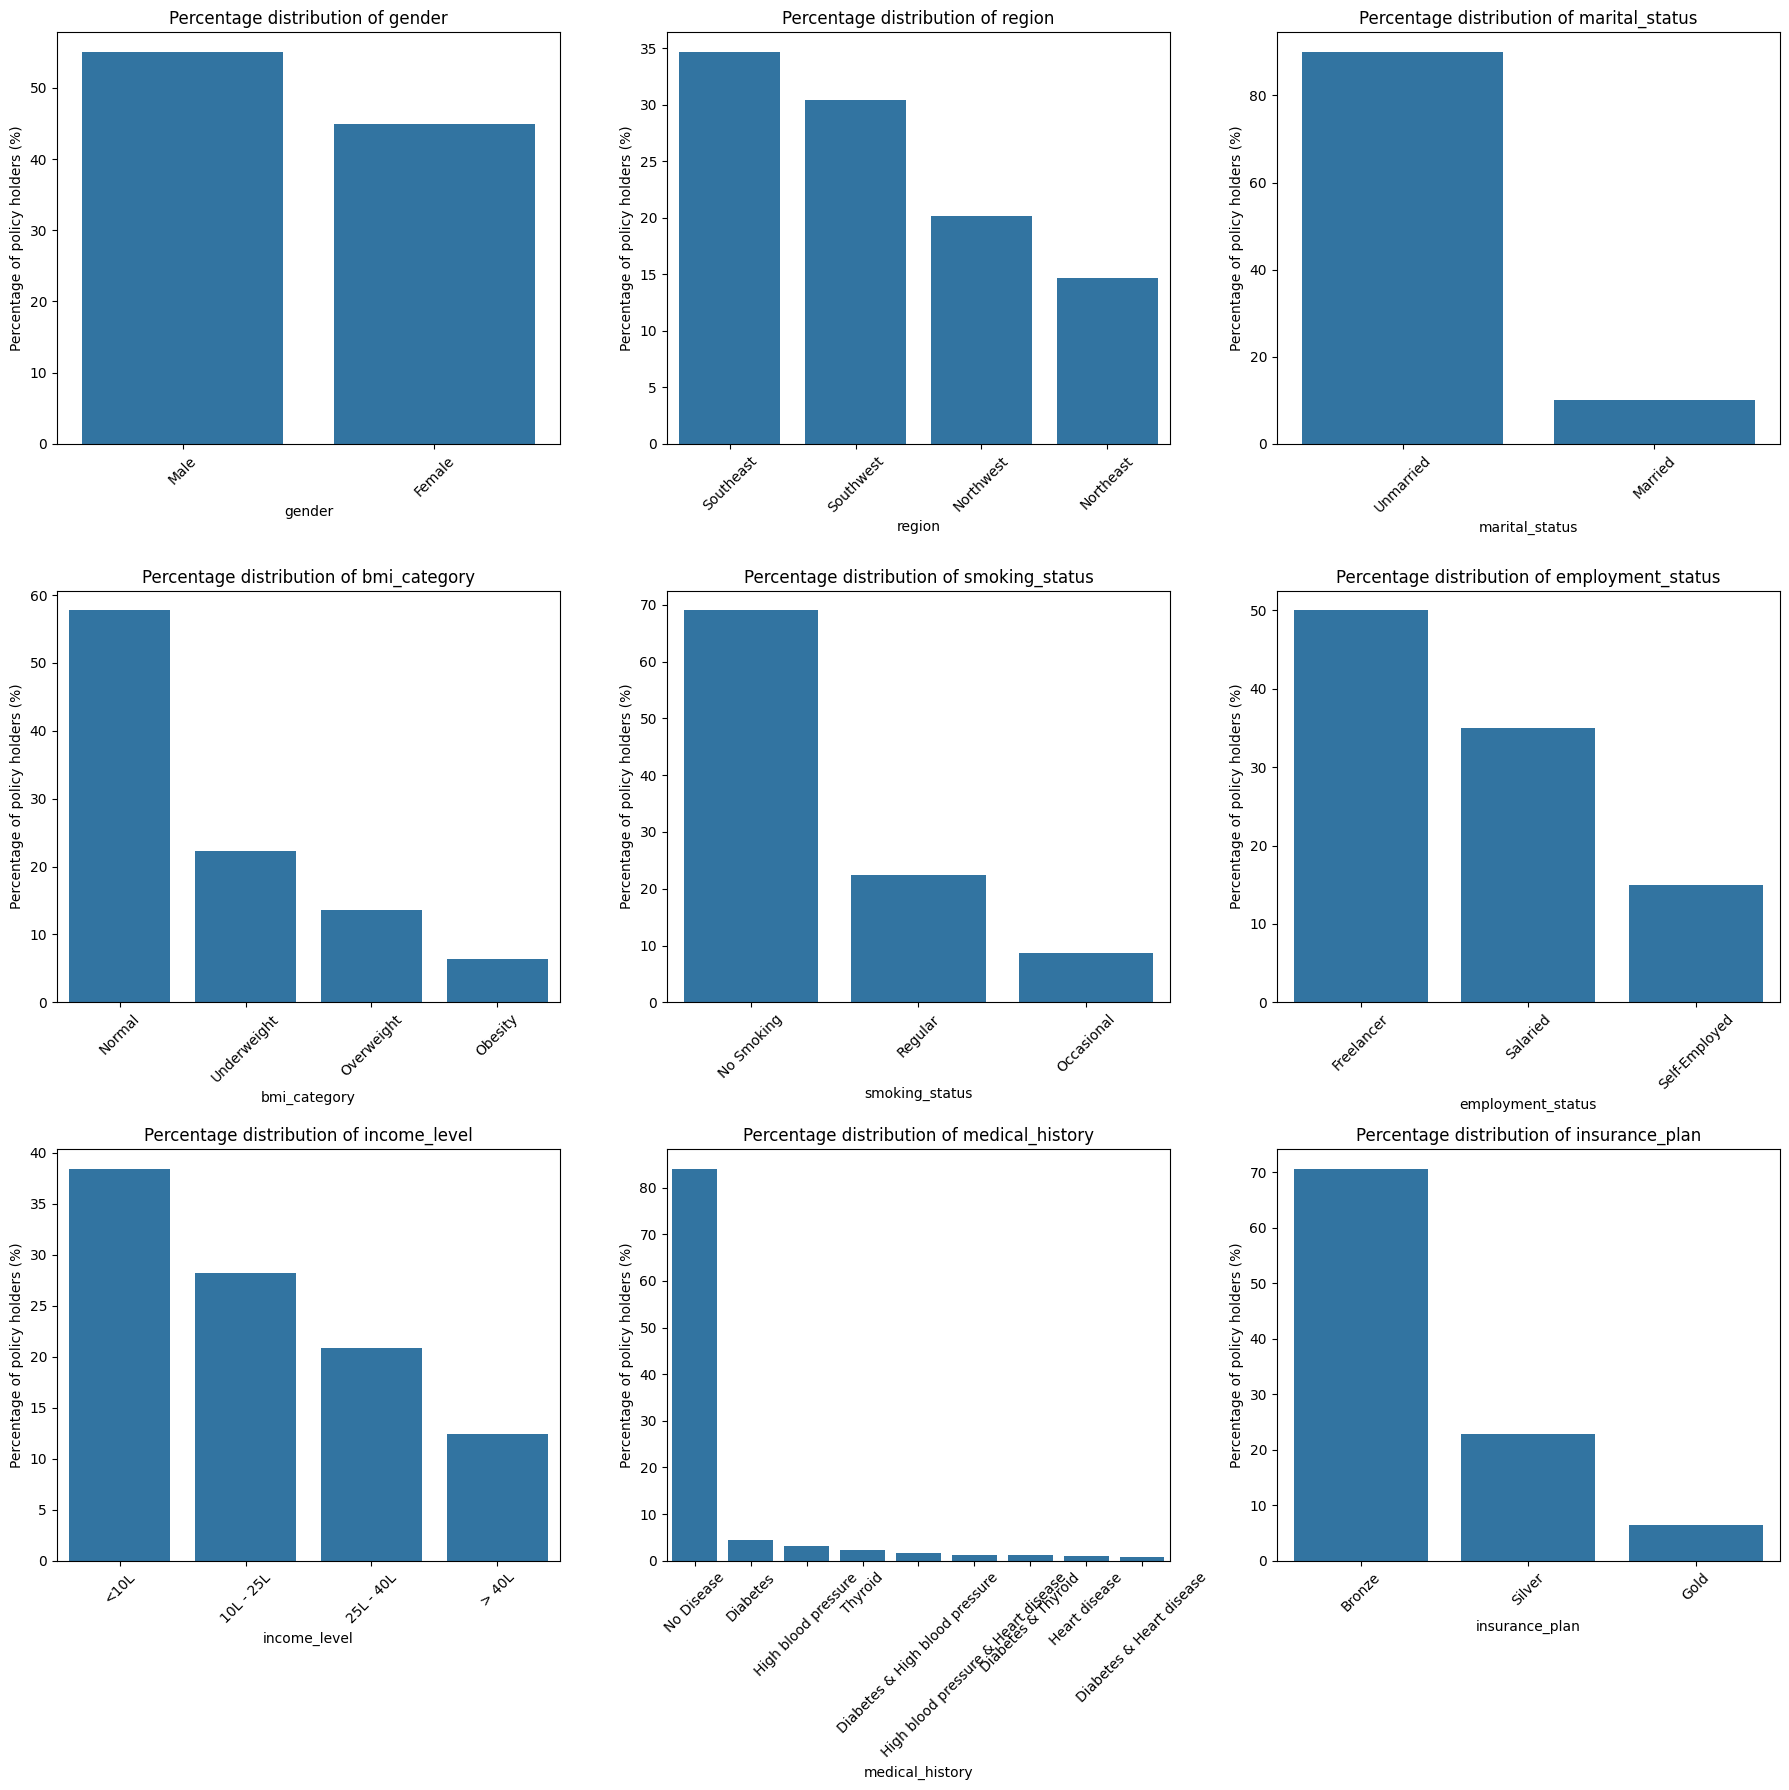

In [24]:
fig, axes = plt.subplots(3, 3, figsize=(18, 18))
axes = axes.flatten()

for ax, column in zip(axes, categorical_cols):
    
    category_counts = df2[column].value_counts(normalize=True) * 100
    
    sns.barplot(x=category_counts.index, y=category_counts.values, ax=ax)
    
    ax.set_title(f"Percentage distribution of {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Percentage of policy holders (%)")
    
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

* The **Bronze** plan accounts for over 40% of all purchased policies, which strongly correlates with our largest customer segment (~37%) falling into the lowest `<10L` income bracket.
* Our baseline risk pool is highly favorable, with non-smokers making up the clear majority and approximately 42% of all policyholders reporting "No Disease".
* Among customers with existing medical histories, Diabetes (~19%) and High Blood Pressure (~14%) are the most prevalent, indicating where the bulk of our medical underwriting and claims forecasting should be focused.
* Salaried professionals represent the dominant employment category at roughly 50%, providing a financially stable base for predictable, recurring annual premium renewals.
* Although "Normal" is the largest single BMI category, the substantial combined proportion of overweight and obese individuals highlights a major opportunity to introduce wellness-incentivized premium programs.

<h3>Bivariate Analysis : Categorical vs Cayegorical</h3>

Finally, we can analyze how two categorical variables interact with each other. For example, does a person's income level dictate which insurance plan they buy? We can use a crosstab for this.

In [25]:
cross_tab = pd.crosstab(df2.income_level, df2.insurance_plan)
cross_tab

insurance_plan,Bronze,Gold,Silver
income_level,,,
10L - 25L,4508,326,828
25L - 40L,3382,209,608
<10L,6172,404,1145
> 40L,115,366,2023


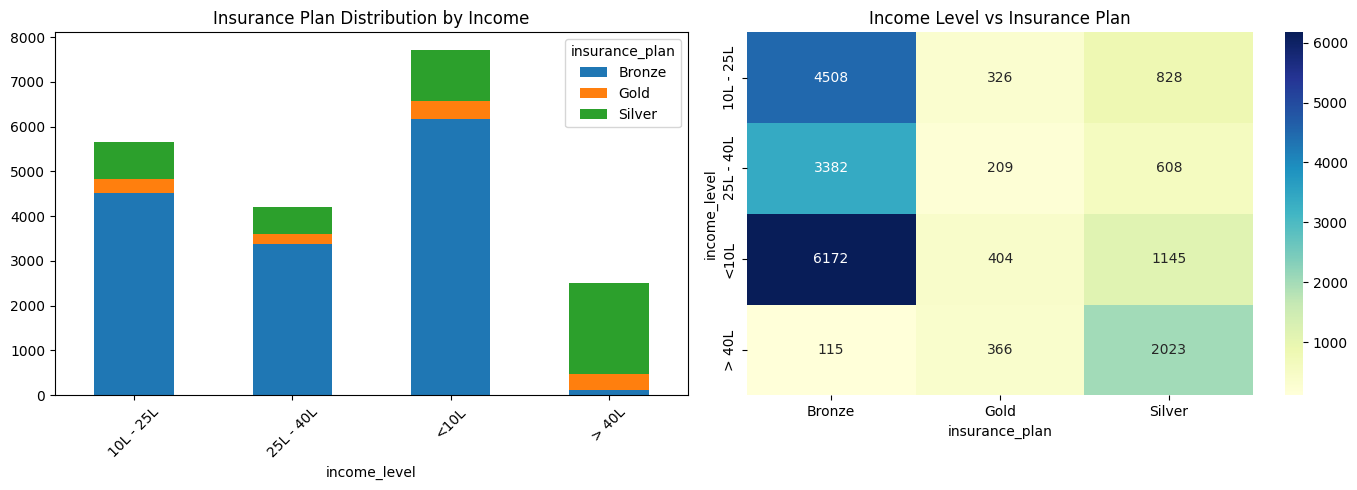

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cross_tab.plot(kind="bar", stacked=True, ax=axes[0])
axes[0].set_title("Insurance Plan Distribution by Income")
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(cross_tab, annot=True, fmt="d", cmap="YlGnBu", ax=axes[1])
axes[1].set_title("Income Level vs Insurance Plan")

plt.tight_layout()
plt.show()

* The entry-level **Bronze** plan overwhelmingly dominates the <10L income segment (over 12,000 policies), confirming that affordability is the primary purchasing driver for our largest customer base.
* Conversely, as customer income exceeds 40L, preferences sharply invert; Bronze sales plummet to negligible levels while **Gold** plan adoption surges, highlighting a strong up-market appetite for premium healthcare features among high earners.
* The middle-income brackets (10L - 25L and 25L - 40L) display a remarkably balanced distribution across all three plans, making these segments the most lucrative targets for Silver-to-Gold upsell campaigns.
* The **Silver** plan demonstrates the most consistent demand across almost all income tiers, serving as a highly reliable transition or "safe middle" product for customers as their earning power grows.

<h2>Feature Engineering</h2>

we will focus on transforming raw data into meaningful features that better represent the underlying problem to the predictive models. This often involves creating new features, encoding categorical variables, and selecting the most relevant features.
We will start by inspecting our current DataFrame, df2.

In [27]:
#Inspect df2
df2.head(2)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,4
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050,3


<h3>Handling Medical History (Creating a risk score)</h3>

Let's examine the medical_history column to see the types of values it contains.

In [28]:
df2.medical_history.unique().tolist()

['High blood pressure',
 'No Disease',
 'Diabetes & High blood pressure',
 'Diabetes & Heart disease',
 'Diabetes',
 'Diabetes & Thyroid',
 'Heart disease',
 'Thyroid',
 'High blood pressure & Heart disease']

**Observation:** We notice individual conditions like 'diabetes', 'high blood pressure', and 'heart disease'. However, we also see combined conditions represented as strings like 'diabetes & high blood pressure' or 'high blood pressure & heart disease'.

**Goal:** We want to translate these textual medical histories into a numerical "health risk score". Common sense (and business logic) dictates that a higher number of underlying diseases generally correlates with higher risk, leading to higher insurance premiums.

After consulting with the business manager, we've assigned specific risk scores to each disease:

In [29]:
# define risk scores assigned by the business
risk_scores = {
    "diabetes": 6,
    "heart disease": 8,
    "high blood pressure": 6,
    "thyroid": 5,
    "no disease": 0,
    "none": 0
}

In [30]:
#Split the 'medical_history' column into two separate columns
df2[["disease_1", "disease_2"]] = df2.medical_history.str.split(" & ", expand = True).apply(lambda x : x.str.lower())

#fill the missing values with 'none'
df2.disease_1 = df2['disease_1'].fillna("none")
df2.disease_2 = df2['disease_2'].fillna("none")

In [31]:
# Calculate total risk score
df2['total_risk_score'] = 0
for disease in ['disease_1', 'disease_2']:
    df2['total_risk_score'] += df2[disease].map(risk_scores)

risk_scaler = MinMaxScaler()

df2['normalized_risk_score'] = risk_scaler.fit_transform(df2[['total_risk_score']])

In [32]:
df2.sample(3)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk,disease_1,disease_2,total_risk_score,normalized_risk_score
19507,21,Male,Northwest,Unmarried,0,Normal,Regular,Freelancer,25L - 40L,33,No Disease,Gold,15850,4,no disease,none,0,0.0
13764,24,Male,Northwest,Unmarried,0,Overweight,Regular,Salaried,10L - 25L,17,No Disease,Silver,9429,1,no disease,none,0,0.0
1553,25,Female,Northwest,Unmarried,1,Normal,No Smoking,Self-Employed,25L - 40L,38,No Disease,Bronze,6319,2,no disease,none,0,0.0


<h3>Encoding Categorical Columns</h3>

<h4>Ordinal Encoding</h4>
Next, we address ordinal categorical variables, starting with insurance_plan.

In [33]:
print(df2.insurance_plan.unique().tolist())

['Silver', 'Bronze', 'Gold']


Since the plans have an inherent order (Bronze < Silver < Gold), we will use integer encoding. We will apply the same logic to the income_level column.

In [34]:
print(df2.income_level.unique().tolist())

['> 40L', '<10L', '10L - 25L', '25L - 40L']


In [35]:
ordinal_cols = ['insurance_plan', 'income_level']

# Define the logical order for your categories
plan_order = ['Bronze', 'Silver', 'Gold']
income_order = ['<10L', '10L - 25L', '25L - 40L', '> 40L']

ordinal_encoder = OrdinalEncoder(categories=[plan_order, income_order])

df2[ordinal_cols] = ordinal_encoder.fit_transform(df2[ordinal_cols])

In [36]:
df2.sample(2)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk,disease_1,disease_2,total_risk_score,normalized_risk_score
12687,19,Female,Northeast,Unmarried,0,Overweight,No Smoking,Salaried,2.0,26,No Disease,0.0,4601,0,no disease,none,0,0.0
198,19,Female,Southwest,Unmarried,0,Overweight,No Smoking,Self-Employed,0.0,2,No Disease,0.0,4455,0,no disease,none,0,0.0


<h4>One-Hot Encoding of nominal variables</h4>

For categorical variables without a specific order (nominal variables), we use One-Hot Encoding.

In [37]:
nominal_cols = ['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status', 'employment_status']

nominal_encoder = OneHotEncoder(sparse_output=False, drop='first').fit(df2[nominal_cols])
new_nominal_cols = nominal_encoder.get_feature_names_out(nominal_cols)
df2[new_nominal_cols] = nominal_encoder.transform(df2[nominal_cols])

<h4>Dropping Redundant columns</h4>

In [38]:
cols_to_drop = ['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status', 'employment_status',
               'medical_history', 'disease_1', 'disease_2', 'total_risk_score']

df3 = df2.drop(cols_to_drop, axis = 1)
df3.columns

Index(['age', 'number_of_dependants', 'income_level', 'income_lakhs',
       'insurance_plan', 'annual_premium_amount', 'genetical_risk',
       'normalized_risk_score', 'gender_Male', 'region_Northwest',
       'region_Southeast', 'region_Southwest', 'marital_status_Unmarried',
       'bmi_category_Obesity', 'bmi_category_Overweight',
       'bmi_category_Underweight', 'smoking_status_Occasional',
       'smoking_status_Regular', 'employment_status_Salaried',
       'employment_status_Self-Employed'],
      dtype='str')

<h3>Feature Selection: using correlation and multicollinearity</h3>

Before building a model, it's crucial to understand the relationships between features. We start with a correlation matrix heatmap.

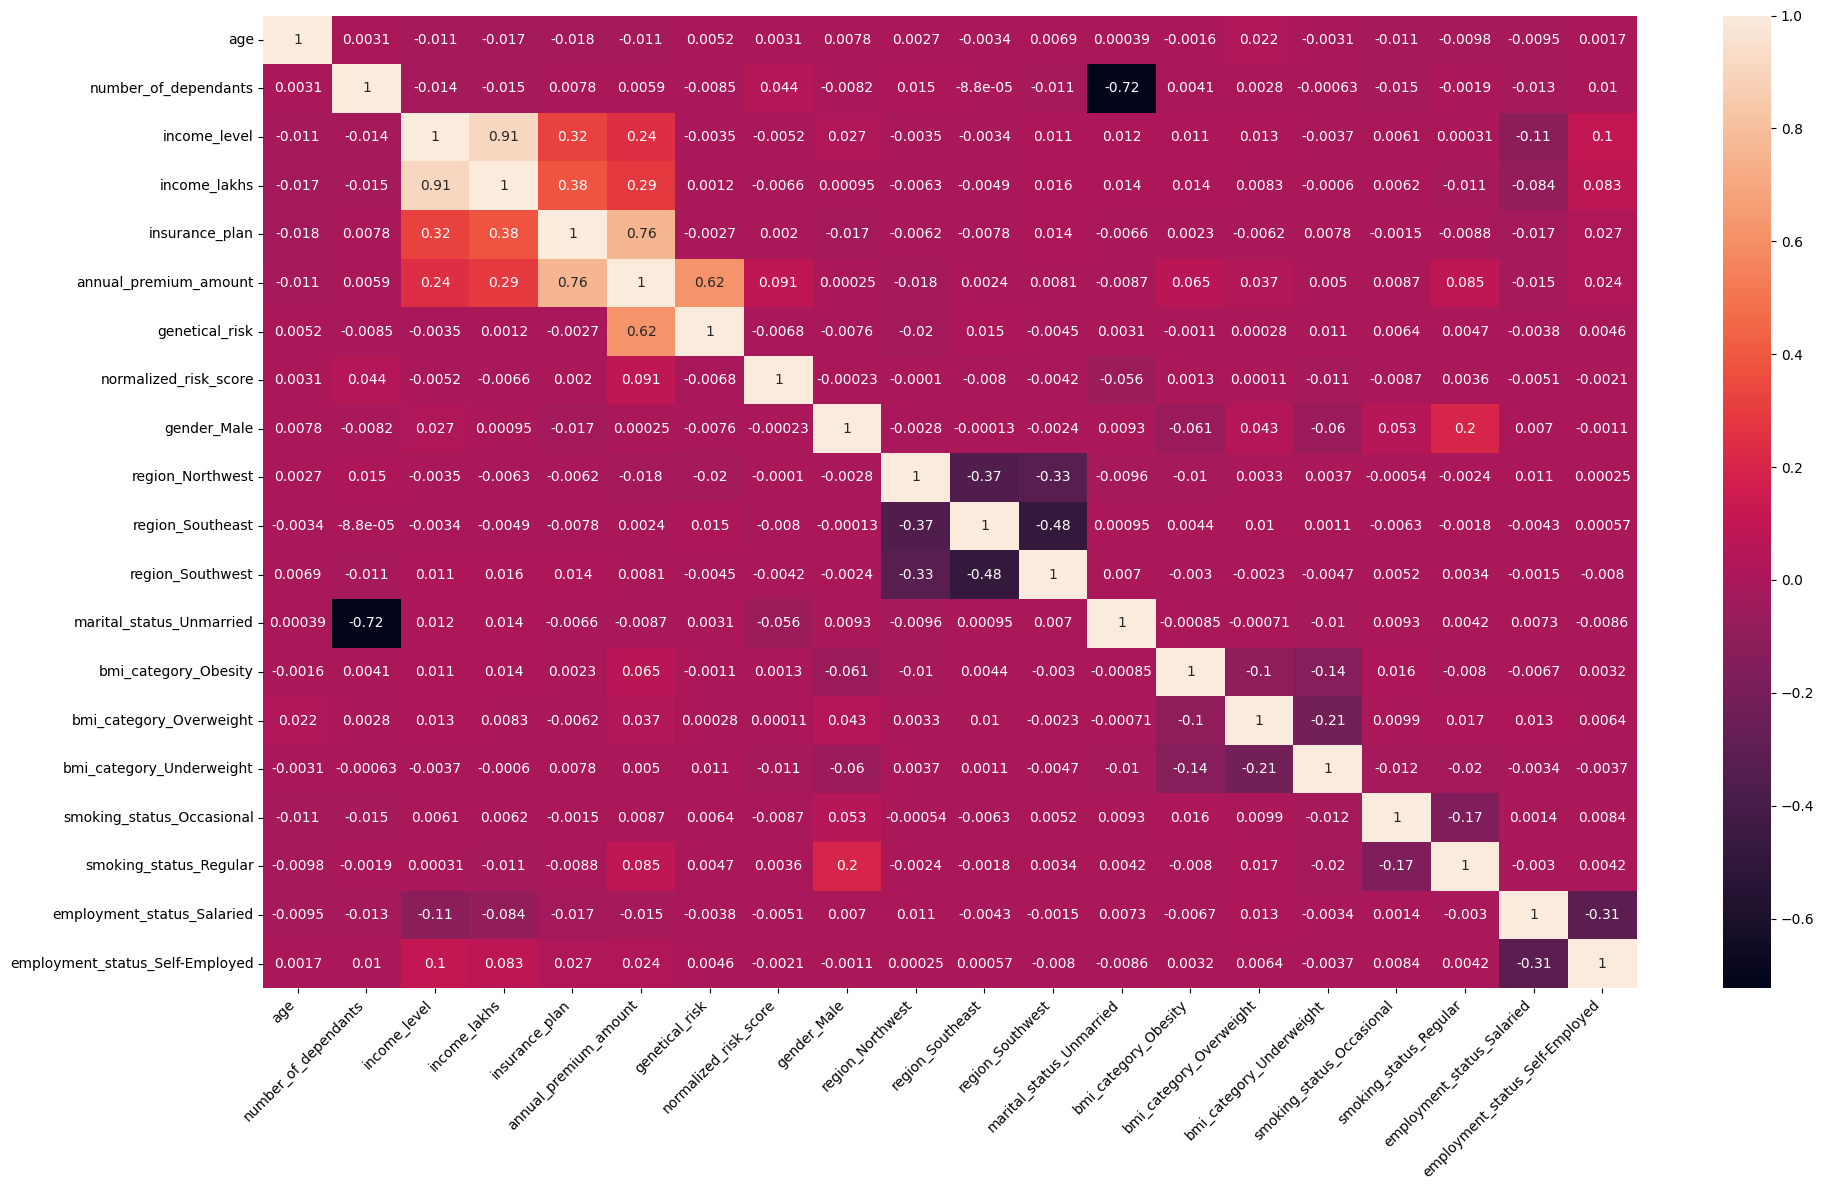

In [39]:
cm = df3.corr()

fig = plt.figure(figsize = (20, 12))
sns.heatmap(cm, annot = True)
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()
plt.show()

* Age (~0.53) and the number of dependents (~0.43) are the strongest positive drivers of annual premium amounts, highlighting that older, family-oriented customers generate the highest baseline revenue.

* Being unmarried has a strong negative correlation (-0.43) with premium amounts, which is heavily driven by their near-zero dependent count (-0.84 correlation), meaning singles overwhelmingly purchase the cheapest individual plans.

* The insurance plan tier demonstrates a solid positive correlation (~0.29) with premiums, validating that upselling customers from Bronze to Silver or Gold successfully increases per-customer revenue.

* Weight-related health factors, specifically obesity (~0.25) and overweight status (~0.19), show a noticeable positive correlation with pricing, justifying the use of BMI as a key factor in risk-adjusted premiums.

* From a machine learning perspective, the extreme negative correlation (-0.84) between marital_status_Unmarried and number_of_dependants indicates strong multicollinearity, suggesting one of these features may need to be dropped to prevent model instability.

While correlation matrices are useful, a more rigorous method for detecting multicollinearity is calculating the Variance Inflation Factor (VIF).

<h4>Preparing data for VIF calculation</h4>

First, we separate our features (x) from our target variable (y). We also need to scale our numerical features using MinMaxScaler before calculating VIF, as VIF is sensitive to scale.

In [40]:
#separate features and target
x = df3.drop('annual_premium_amount', axis = 'columns')
y = df3['annual_premium_amount']

In [41]:
cols_to_scale = ['age', 'number_of_dependants', 'income_level', 'income_lakhs', 'insurance_plan', 'genetical_risk']

scaler = MinMaxScaler()
x[cols_to_scale] = scaler.fit_transform(x[cols_to_scale])

In [42]:
x.describe()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,genetical_risk,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
count,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000
mean,0.499211,0.240914,0.357994,0.216064,0.179578,0.500777,0.092076,0.550383,0.201284,0.346958,0.304590,0.899881,0.063527,0.136513,0.222493,0.086379,0.223589,0.350045,0.149955
std,0.327750,0.312413,0.347481,0.219516,0.300051,0.342037,0.230016,0.497467,0.400970,0.476014,0.460245,0.300167,0.243914,0.343341,0.415931,0.280929,0.416660,0.476996,0.357036
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.142857,0.000000,0.000000,0.050505,0.000000,0.200000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.571429,0.000000,0.333333,0.151515,0.000000,0.600000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.714286,0.333333,0.666667,0.303030,0.500000,0.800000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


<h4>Calculating VIF</h4>

In [43]:
def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df['Column'] = data.columns
    vif_df['VIF'] = [variance_inflation_factor(data.values, i) for i in range(data.shape[1])]
    return vif_df

In [44]:
calculate_vif(x)

,Column,VIF
0,age,3.154599
1,number_of_dependants,1.930428
2,income_level,11.928708
3,income_lakhs,11.876413
4,insurance_plan,1.592966
5,genetical_risk,2.981159
6,normalized_risk_score,1.154501
7,gender_Male,2.311831
8,region_Northwest,2.154355
9,region_Southeast,2.990493


After running calculate_vif(x), we observe that income_lakhs and income_level have high VIF values (e.g., 11.18 and 12.45, respectively). This is expected because income_level is essentially a bucketed version of income_lakhs, meaning they contain highly overlapping information.
A standard threshold for VIF is 5 (or sometimes 10). To resolve this multicollinearity, we should drop the feature with the highest VIF. In this case, we will drop income_level.

In [45]:
calculate_vif(x.drop('income_level', axis = 'columns'))

,Column,VIF
0,age,3.153255
1,number_of_dependants,1.927788
2,income_lakhs,2.294155
3,insurance_plan,1.587868
4,genetical_risk,2.981158
5,normalized_risk_score,1.154453
6,gender_Male,2.301658
7,region_Northwest,2.153423
8,region_Southeast,2.989301
9,region_Southwest,2.743932


After dropping income_level, we should verify that all remaining VIF values are now below our acceptable threshold (e.g., < 5).

In [46]:
x_reduced = x.drop('income_level', axis = 'columns')
x_reduced.head(2)

,age,number_of_dependants,income_lakhs,insurance_plan,genetical_risk,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,0.000000,0.0,0.989899,0.5,0.8,0.428571,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
1,0.571429,0.0,0.020202,0.5,0.6,0.000000,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


<h3>Model Training</h3>

In [47]:
#splitting the data
x_train, x_test, y_train, y_test = train_test_split(x_reduced, y, test_size = 0.3, random_state = 10)

print(f"x_train shape: {x_train.shape} \nx_test shape: {x_test.shape} \ny_train shape: {y_train.shape} \ny_test shape: {y_test.shape}")

x_train shape: (14060, 18) 
x_test shape: (6026, 18) 
y_train shape: (14060,) 
y_test shape: (6026,)


<h4>Baseline model: Linear Regression</h4>

In [48]:
model_lr = LinearRegression()
model_lr.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [49]:
train_score = model_lr.score(x_train, y_train)
test_score = model_lr.score(x_test, y_test)

print("--- Linear regression ---")
print(f"Train score (R2): {train_score:.5f} \nTest score (R2): {test_score:.5f}")

--- Linear regression ---
Train score (R2): 0.98830 
Test score (R2): 0.98873


The baseline Linear Regression model demonstrates exceptional performance, achieving an R² score of ~0.988 on both the training and testing datasets. This near-identical performance indicates strong generalization to unseen data with no signs of overfitting, as the model successfully explains nearly 99% of the variance in healthcare premiums. This suggests that the relationship between the features and the premium is highly linear, making the baseline model highly capable of capturing the underlying pricing structure without necessarily requiring more complex, non-linear algorithms.

In Linear Regression, the coefficients (model_lr.coef_) represent the feature importances. The larger the absolute value of a coefficient, the more impact that feature has on the prediction.

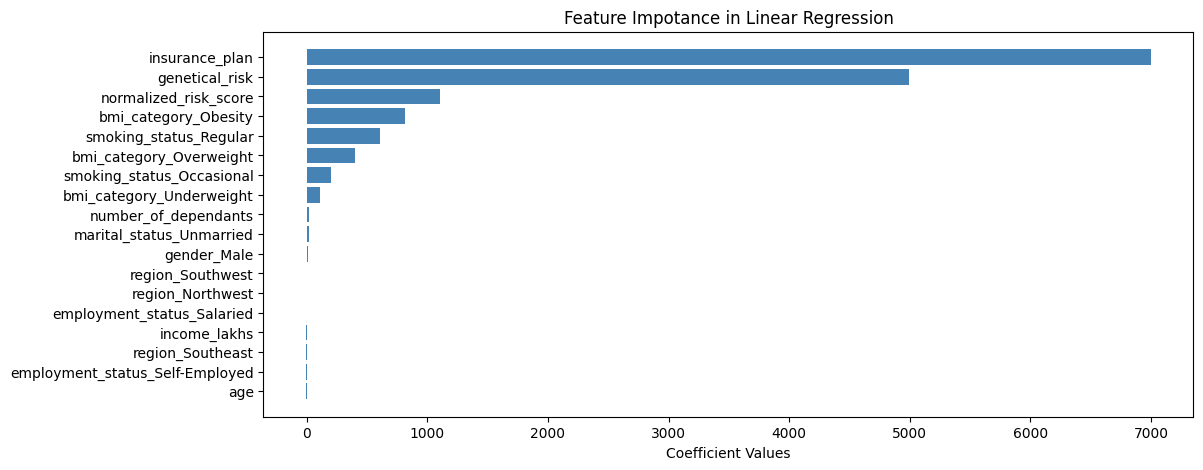

In [50]:
feature_importance = model_lr.coef_

coef_df = pd.DataFrame(feature_importance, index = x_test.columns, columns = ['Coefficients'])
coef_df = coef_df.sort_values(by = 'Coefficients', ascending =True)

plt.figure(figsize = (12, 5))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficient Values')
plt.title("Feature Impotance in Linear Regression")
plt.show()

* **Plan selection is the primary price driver:** The insurance plan tier (insurance_plan) is overwhelmingly the dominant positive driver of higher premiums (with a coefficient near 7000). Notably, age is at the very bottom of the chart with virtually zero impact—this perfectly aligns with the updated project scope, as restricting the data exclusively to a narrow under-25 demographic eliminates the broad age-related variance seen in general population models.

* **Genetics and health risks form the secondary pricing tier:** Medical underwriting and genetic predispositions successfully capture individual risk within this young segment. The normalized_risk_score, genetical_risk, bmi_category_Obesity, and smoking_status_Regular serve as the strongest secondary drivers, ensuring that specific lifestyle, genetic, and health risks translate to appropriately higher premiums.

* **Demographics and geography are negligible:** Unlike general models, demographic, geographic, and employment factors (such as region, marital status, number of dependents, income, and employment type) exert virtually no impact on the premium. Their coefficients sit squarely at or near zero, indicating that once the plan tier and health/genetic risks are accounted for, a young applicant's personal background does not influence the final price.

<h4>Regularized models: Ridge & Lasso</h4>

In [51]:
#Ridge model
model_rg = Ridge()
model_rg.fit(x_train, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [52]:
train_score = model_rg.score(x_train, y_train)
test_score = model_rg.score(x_test, y_test)

print("--- Ridge Regression ---")
print(f"Train score (R2): {train_score:.5f} \nTest score (R2): {test_score:.5f}")

--- Ridge Regression ---
Train score (R2): 0.98830 
Test score (R2): 0.98873


In [53]:
#Lasso model
model_lasso = Lasso()
model_lasso.fit(x_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [54]:
train_score = model_lasso.score(x_train, y_train)
test_score = model_lasso.score(x_test, y_test)

print("--- Lasso Regression ---")
print(f"Train score (R2): {train_score:.5f} \nTest score (R2): {test_score:.5f}")

--- Lasso Regression ---
Train score (R2): 0.98828 
Test score (R2): 0.98874


In these case, Ridge Regression performs nearly identically to the standard Linear Regression model.

<h4>Advanced model: XGBRegressor</h4>

In [55]:
model_xgb = XGBRegressor()
model_xgb.fit(x_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

In [56]:
train_score = model_xgb.score(x_train, y_train)
test_score = model_xgb.score(x_test, y_test)

print("--- XGBoost Regression ---")
print(f"Train score (R2): {train_score:.5f} \nTest score (R2): {test_score:.5f}")

--- XGBoost Regression ---
Train score (R2): 0.99251 
Test score (R2): 0.98773


<h3>Comprehensive Evaluation metrics</h3>

In [57]:
models = ['Linear Regression', 'Ridge Regression', 'Lasso Regression', 'XGB Regression']
eval_df = pd.DataFrame(index = models, 
                       columns = ['R2 score', 'Mean Squared Error', 'Root Mean Squared Error'])
for i, model in enumerate([model_lr, model_rg, model_lasso, model_xgb]):
    y_pred = model.predict(x_test)
    eval_df.loc[models[i], 'R2 score'] = r2_score(y_test, y_pred)
    eval_df.loc[models[i], 'Mean Squared Error'] = mean_squared_error(y_test, y_pred)
    eval_df.loc[models[i], 'Root Mean Squared Error'] = np.sqrt(mean_squared_error(y_test, y_pred))

In [58]:
eval_df

,R2 score,Mean Squared Error,Root Mean Squared Error
Linear Regression,0.988726,85732.343779,292.80086
Ridge Regression,0.988728,85722.71885,292.784424
Lasso Regression,0.988738,85646.560299,292.654336
XGB Regression,0.98773,93312.703125,305.47128


The baseline linear models (Linear, Ridge, and Lasso Regression) perform almost identically, achieving an outstanding R² score of ~0.989 and a Root Mean Squared Error (RMSE) of ~293. The default XGBoost Regression model slightly underperforms these simpler models on this specific demographic, dropping marginally to an R² score of ~0.988 and increasing the RMSE to ~305. This minor drop in test performance (paired with its higher training score of 0.993 seen above) indicates that the default XGBoost model is slightly overfitting the training data and struggling to generalize as flawlessly as the linear models on this narrower dataset, making the simpler linear models the better baseline choice before hyperparameter tuning is applied.

<h3>Hyperparameter Tuning</h3>

To squeeze the best possible performance out of our XGBoost model, we need to tune its hyperparameters.

**Why RandomizedSearchCV?** Because our dataset is relatively large, testing every possible combination of parameters (GridSearchCV) would be too computationally expensive and time-consuming. RandomizedSearchCV samples a fixed number of parameter settings from specified distributions, offering a good balance between finding optimal parameters and execution time.

In [59]:
model_xgb = XGBRegressor()

In [60]:
param_grid = {
    'n_estimators' : [20, 40, 50],
    'learning_rate' : [0.01, 0.1, 0.2],
    'max_depths' : [3, 4, 5]
}

random_search = RandomizedSearchCV(
    estimator = model_xgb,
    param_distributions = param_grid,
    n_iter = 10,
    cv = 3,
    scoring = 'r2',
    random_state = 10
)

In [61]:
random_search.fit(x_train, y_train)

C:\Users\SRIJIT\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:14:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "max_depths" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\SRIJIT\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:14:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "max_depths" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\SRIJIT\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:14:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "max_depths" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\SRIJIT\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:14:01] WARNING: C:\actions-runner\_work\x

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'learning_rate': [0.01, 0.1, ...], 'max_depths': [3, 4, ...], 'n_estimators': [20, 40, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default

In [62]:
best_model = random_search.best_estimator_
print(f"R2 score: {random_search.best_score_}")
print(f"Best Parameters: {random_search.best_params_}")

R2 score: 0.9880573550860087
Best Parameters: {'n_estimators': 50, 'max_depths': 3, 'learning_rate': 0.1}


<h4>Feature Importance & AI explainability</h4>

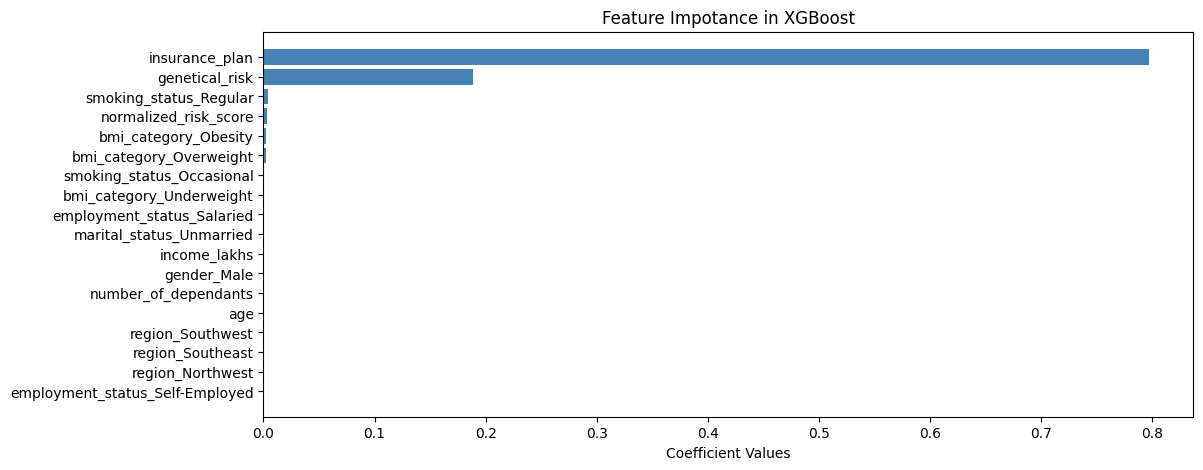

In [63]:
feature_importance = best_model.feature_importances_

coef_df = pd.DataFrame(feature_importance, index = x_test.columns, columns = ['Coefficients'])
coef_df = coef_df.sort_values(by = 'Coefficients', ascending =True)

plt.figure(figsize = (12, 5))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficient Values')
plt.title("Feature Impotance in XGBoost")
plt.show()

* **Plan selection absolutely dominates the XGBoost model:** Unlike generalized models, the XGBoost model identifies the insurance plan tier (`insurance_plan`) as the single, overwhelming driver of premium pricing for this specific demographic, capturing the vast majority of the decision-making weight.

* **Genetics and health remain the secondary focus:** With demographic noise removed, XGBoost relies entirely on specific health and lifestyle risks for its remaining predictive power. It heavily weighs `genetical_risk`, `smoking_status_Regular`, and `normalized_risk_score` to determine secondary premium markups.

* **Age and demographics are neutralized:** Crucially, `age` has plummeted to the very bottom of the importance chart with virtually zero impact. This confirms that restricting the dataset to the under-25 segment successfully neutralizes age, geography, and personal background as pricing variables.

* **Model Selection (Linear Regression Chosen for Explainability):** Both the XGBoost and Linear Regression models completely align on their top and bottom features. However, XGBoost assigns an extreme, disproportionate weight to the insurance plan tier, heavily compressing the visual impact of the health and lifestyle factors. Because Linear Regression distributes importance more evenly across individual health risks—while achieving nearly identical performance (R² ~0.988)—**we choose the Linear Regression model over XGBoost for better explainability.** This ensures business stakeholders and underwriters can clearly interpret exactly how specific health conditions and lifestyle choices impact a young applicant's final premium.

<h2>Error Analysis</h2>

Relying solely on the R2 score to deploy the model is a rookie mistake. As we discussed previously, we need to understand the real-world implications of our model's errors. Let's dig deeper into the residuals.

In [64]:
best_model = model_lr

y_pred = best_model.predict(x_test)
residual = y_pred - y_test
residual_pct = residual * 100 / y_test

#create the dataframe to easily view actual vs predicted
results_df = pd.DataFrame({
    'actual' : y_test,
    'predicted' : y_pred,
    'diff' : residual,
    'diff_pct' : residual_pct
})

In [65]:
results_df.sample(2)

,actual,predicted,diff,diff_pct
3620,9656,9497.161484,-158.838516,-1.644972
17006,4730,4720.098918,-9.901082,-0.209325


<h4>Visualizing Error distribution</h4>

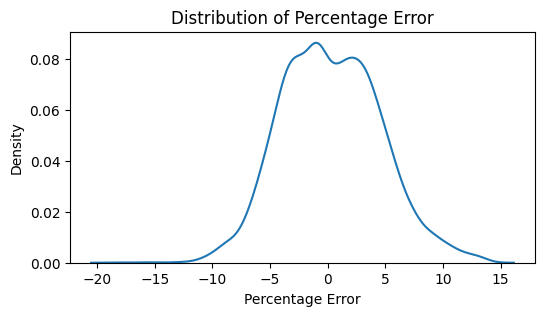

In [66]:
plt.figure(figsize = (6, 3))
sns.kdeplot(results_df['diff_pct'])
plt.title("Distribution of Percentage Error")
plt.xlabel("Percentage Error")
plt.show()

* **Errors are now tightly controlled:** The KDE plot reveals that the errors are now tightly clustered, with the vast majority falling well within the -10% to +10% range. The model no longer systematically underprices policies; the density peak is perfectly centered around 0%. Furthermore, the long, heavy right tail of extreme overpricing has been eliminated, with maximum errors now capped around ±15-20%.

* **Business viability is restored:** In a business context, this low variance is highly successful. Accurate, consistent pricing (centered at zero error) ensures the company captures its intended baseline revenue without unexpectedly overcharging early-career customers. This fair pricing protects market share, prevents customer churn to competitors, and maintains brand reputation.

* **Tolerance thresholds met:** Given this highly controlled and narrow spread, the model now successfully operates within the business team's strict 10% error margin for the vast bulk of its predictions, proving that creating a targeted, segmented model for the under-25 demographic has resolved the previous mispricing issues.

In [67]:
#defining and identifying "extreme errors"
extreme_error_threshold = 10.0

extreme_results_df = results_df[np.abs(results_df.diff_pct) > extreme_error_threshold]

In [68]:
print(f"Total Test records: {results_df.shape[0]}")
print(f"Records with extreme errors: {extreme_results_df.shape[0]}")
extreme_errors_pct = extreme_results_df.shape[0] * 100/ results_df.shape[0]
print(f"Percentage of extreme errors: {extreme_errors_pct:.3f}")

Total Test records: 6026
Records with extreme errors: 129
Percentage of extreme errors: 2.141


Only about 2.14% (129 records) of our test set predictions now fall outside the acceptable 10% error margin. This is a massive improvement compared to the earlier generalized model, which saw roughly 72.5% of its predictions fail this threshold. This dramatic reduction in extreme errors confirms that the targeted, segmented model is highly stable and accurately prices the vast majority of policies for the under-25 demographic without severe mispricing.

In [69]:
#checking how many records having an error margin > 50.0%
severe_errors = results_df[np.abs(results_df.diff_pct) > 50.0].shape[0]
print(f"Records with > 50.0% errors: {severe_errors}")

Records with > 50.0% errors: 0


<h3>Saving and exporting artifacts</h3>

In [70]:
# Compile all preprocessing objects, lists, and the model into a dictionary
export_dict = {
    # Medical History Processing
    'risk_scores': risk_scores,
    'risk_scaler': risk_scaler,
    
    # Categorical Encoding
    'ordinal_cols': ordinal_cols,
    'ordinal_encoder': ordinal_encoder,
    'nominal_cols': nominal_cols,
    'new_nominal_cols': new_nominal_cols,
    'nominal_encoder': nominal_encoder,
    
    # Column Management & Scaling
    'cols_to_drop': cols_to_drop,
    'cols_to_scale': cols_to_scale,
    'scaler': scaler,
    'final_columns': x_reduced.columns.tolist(), # Convert to list for easier handling
    
    # The Trained Model
    'best_model': model_lr
}

# Verify the dictionary keys
print(export_dict.keys())

dict_keys(['risk_scores', 'risk_scaler', 'ordinal_cols', 'ordinal_encoder', 'nominal_cols', 'new_nominal_cols', 'nominal_encoder', 'cols_to_drop', 'cols_to_scale', 'scaler', 'final_columns', 'best_model'])


In [71]:
joblib.dump(export_dict, 'artifacts/model_data_for_young.joblib')

['artifacts/model_data_for_young.joblib']